In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecVideoRecorder
import os 
import do_mpc
from casadi import vertcat
from scipy.linalg import solve_discrete_are
import time
import copy
import mujoco
import cv2


c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\sysid\__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\opcua\__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


## Mujoco cartpole gym env

https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/

https://gymnasium.farama.org/tutorials/training_agents/reinforce_invpend_gym_v26/ 

https://github.com/google-deepmind/mujoco_mpc/blob/main/python/mujoco_mpc/demos/predictive_sampling/predictive_sampling.py

https://github.com/mohakbhardwaj/mjmpc/tree/master/mjmpc/control

### Show the initial state

| Num | Observation                              | Min   | Max   | Name (in corresponding XML file) | Joint  | Type (Unit)               | `qpos` Index | `qvel` Index |
|-----|------------------------------------------|-------|-------|----------------------------------|--------|---------------------------|--------------|--------------|
| 0   | Position of the cart along the linear surface | -Inf  | Inf   | slider                           | slide  | position (m)              | **0**        |              |
| 1   | Vertical angle of the pole on the cart   | -Inf  | Inf   | hinge                            | hinge  | angle (rad)               | **1**        |              |
| 2   | Linear velocity of the cart              | -Inf  | Inf   | slider                           | slide  | velocity (m/s)            |              | **0**        |
| 3   | Angular velocity of the pole on the cart | -Inf  | Inf   | hinge                            | hinge  | angular velocity (rad/s)  |              | **1**        |


Initial state: [-0.08547714  0.08816452 -0.09058629 -0.0336848 ]


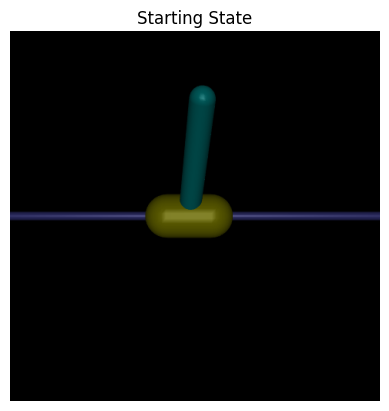

In [ ]:
env = gym.make('InvertedPendulum-v5', render_mode="rgb_array", reset_noise_scale=0.1) #reset_noise_scale = Scale of random perturbations of initial position and velocity 

# Reset the environment to get the initial state
observation, info = env.reset()

# Print the state vector
print("Initial state:", observation)

# Render the initial frame
frame = env.render()

# Show the frame using matplotlib
plt.imshow(frame)
plt.axis('off')  # Hide axes
plt.title("Starting State")
plt.show()


### Show the action space

| Num | Action                   | Control Min | Control Max | Name (in corresponding XML file) | Joint | Type (Unit) |
|-----|--------------------------|--------------|--------------|----------------------------------|--------|--------------|
| 0   | Force applied on the cart | -3           | 3            | slider                           | slide  | Force (N)    |


In [ ]:
# Print the action space
print("Action space:", env.action_space)

# Print one action
print("Initial action:", env.action_space.sample())

Action space: Box(-3.0, 3.0, (1,), float32)
Initial action: [-1.3308493]


### Save and restore the initial state


--- STATE COMPARISON ---
Initial qpos:   [ 0.00456071 -0.00875223]
Initial qvel:   [ 0.0029965 -0.0087749]
Next qpos:      [-0.01261781  0.03073045]
Next qvel:      [-0.85951186  1.9626858 ]
Restored qpos:  [ 0.00456071 -0.00875223]
Restored qvel:  [ 0.0029965 -0.0087749]


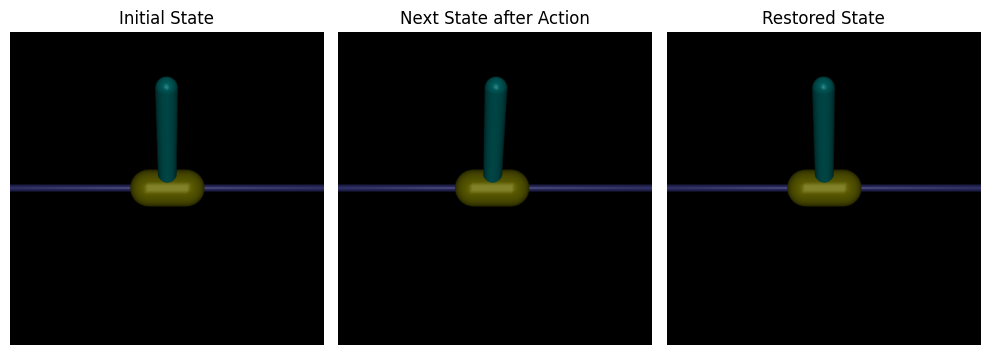

In [ ]:
# Create the environment
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")

# Reset the environment
obs, info = env.reset()

# Save true simulation state using deep copy
initial_data = copy.deepcopy(env.unwrapped.data)
initial_qpos = initial_data.qpos.copy()
initial_qvel = initial_data.qvel.copy()

# Render initial state
frame_initial = env.render()

# Take a random action
action = env.action_space.sample()

# Step the environment
next_obs, reward, done, truncated, info = env.step(action)

# Save next state
next_qpos = env.unwrapped.data.qpos.copy()
next_qvel = env.unwrapped.data.qvel.copy()

# Render next state
frame_next = env.render()

# Restore simulation state
env.unwrapped.data.qpos[:] = initial_qpos
env.unwrapped.data.qvel[:] = initial_qvel
mujoco.mj_forward(env.unwrapped.model, env.unwrapped.data)

# Get restored state
restored_qpos = env.unwrapped.data.qpos.copy()
restored_qvel = env.unwrapped.data.qvel.copy()

# Render restored state
frame_restored = env.render()

# Print state vectors
print("\n--- STATE COMPARISON ---")
print(f"Initial qpos:   {initial_qpos}")
print(f"Initial qvel:   {initial_qvel}")
print(f"Next qpos:      {next_qpos}")
print(f"Next qvel:      {next_qvel}")
print(f"Restored qpos:  {restored_qpos}")
print(f"Restored qvel:  {restored_qvel}")

# Compare visually
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(frame_initial)
plt.title("Initial State")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(frame_next)
plt.title("Next State after Action")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(frame_restored)
plt.title("Restored State")
plt.axis('off')

plt.tight_layout()
plt.show()

env.close()


### Do some random sampling to balance the pole

In [ ]:
# Create the environment
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")

# Reset the environment
obs, info = env.reset()
done = False
step_count = 0
max_steps = 200
n_samples = 2000

# Create a VideoWriter object to save the video
video_filename = "simulation_output.mp4"
frame_width = env.render().shape[1]  # Width of the rendered frame
frame_height = env.render().shape[0]  # Height of the rendered frame
fourcc = cv2.VideoWriter_fourcc(*"MP4V")  # Codec for MP4 format
video_writer = cv2.VideoWriter(video_filename, fourcc, 30, (frame_width, frame_height))

# Function to get a random action
def get_action(observation):
    return env.action_space.sample()

# Function to evaluate the action and save the state using qpos and qvel
def evaluate_action(env, action):
    # Save the current state of the environment using qpos and qvel
    saved_qpos = copy.deepcopy(env.unwrapped.data.qpos)
    saved_qvel = copy.deepcopy(env.unwrapped.data.qvel)
    
    # Perform the step
    obs_, reward, done, truncated, info = env.step(action)
    
    # Return the reward, done status, and the saved state
    return reward, done, (saved_qpos, saved_qvel)

# Function to sample actions and evaluate them
def sample_and_evaluate(env, obs, n=10):
    best_action = None
    best_reward = float('-inf')
    
    for _ in range(n):
        action = get_action(obs)
        reward, done, env_state = evaluate_action(env, action)
        
        # Restore the environment's state
        saved_qpos, saved_qvel = env_state
        env.unwrapped.data.qpos[:] = saved_qpos
        env.unwrapped.data.qvel[:] = saved_qvel

        # We need to call mujoco.mj_forward to update the simulation state with the restored positions and velocities.
        # This function ensures that all the states are correctly computed after restoring the qpos and qvel.
        mujoco.mj_forward(env.unwrapped.model, env.unwrapped.data)
        
        # Update the best action if the reward is better
        if reward > best_reward:
            best_reward = reward
            best_action = action
    
    return best_action

# Main loop
while step_count < max_steps:
    action = sample_and_evaluate(env, obs, n=n_samples)
    obs, reward, done, truncated, info = env.step(action)
    step_count += 1

    # Render the frame
    frame = env.render()
    
    # Write the frame to the video
    video_writer.write(frame)

# Release the VideoWriter object and close the environment
video_writer.release()
env.close()


## TO DO

- Implement smarter sampling from: https://arxiv.org/abs/1803.07055
- Discuss whether to stick to gymnasium or do things directly in Mujoco API

# The two things that we need to integrate are in run.py and models.py.